# Imports

In [1]:
!pip install pytabkit    

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 7.4 MB/s eta 0:00:00


In [2]:
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

# Global Configuration

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
N_FOLDS = 5

print(f"Using device: {DEVICE}")

Using device: cuda


# Data Loading and Preprocessing

In [4]:
train = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")
original = pd.read_csv("/kaggle/input/heartdisease/Heart_Disease_Prediction.csv") 

le = LabelEncoder()
train['Heart Disease'] = le.fit_transform(train['Heart Disease'])
original['Heart Disease'] = le.fit_transform(original['Heart Disease'])

base_features = [col for col in train.columns if col not in ['Heart Disease', 'id']] 

def add_engineered_features(df):
    df_temp = df.copy()
    
    for col in base_features: 
        if col in original.columns:
           
            stats = original.groupby(col)['Heart Disease'].agg(['mean', 'median', 'std', 'skew', 'count']).reset_index()
         
            stats.columns = [col] + [f"orig_{col}_{s}" for s in ['mean', 'median', 'std', 'skew', 'count']]
     
            df_temp = df_temp.merge(stats, on=col, how='left') 
 
            fill_values = {
                f"orig_{col}_mean": original['Heart Disease'].mean(),
                f"orig_{col}_median": original['Heart Disease'].median(),
                f"orig_{col}_std": 0,
                f"orig_{col}_skew": 0,
                f"orig_{col}_count": 0
            }
            df_temp = df_temp.fillna(value=fill_values)
            
    return df_temp

train = add_engineered_features(train)
test = add_engineered_features(test) 

X = train.drop(['id', 'Heart Disease'], axis=1)
y = train['Heart Disease']
X_test = test.drop(['id'], axis=1)

# Data Quality Check (Missing & Duplicates)

In [5]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()
    
    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


# Feature Uniqueness & Cardinality

In [6]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id': continue
        
        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"
        
        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })
    
    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
print(uniqueness_df)

                     Feature  Unique Values Data Type       Heuristic Type
40  orig_FBS over 120_median              1   float64  Categorical/Ordinal
1                        Sex              2     int64  Categorical/Ordinal
13             Heart Disease              2     int64  Categorical/Ordinal
5               FBS over 120              2     int64  Categorical/Ordinal
20           orig_Sex_median              2   float64  Categorical/Ordinal
..                       ...            ...       ...                  ...
0                        Age             42     int64           Continuous
3                         BP             66     int64           Continuous
9              ST depression             66   float64           Continuous
7                     Max HR             93     int64           Continuous
4                Cholesterol            150     int64           Continuous

[79 rows x 4 columns]


# Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
orig_EKG results_count   -15.613416
orig_EKG results_std       6.747575
orig_Slope of ST_count    -5.657311
orig_Thallium_std          4.472673
orig_BP_std               -4.174508
orig_Age_std              -3.145546
dtype: float64


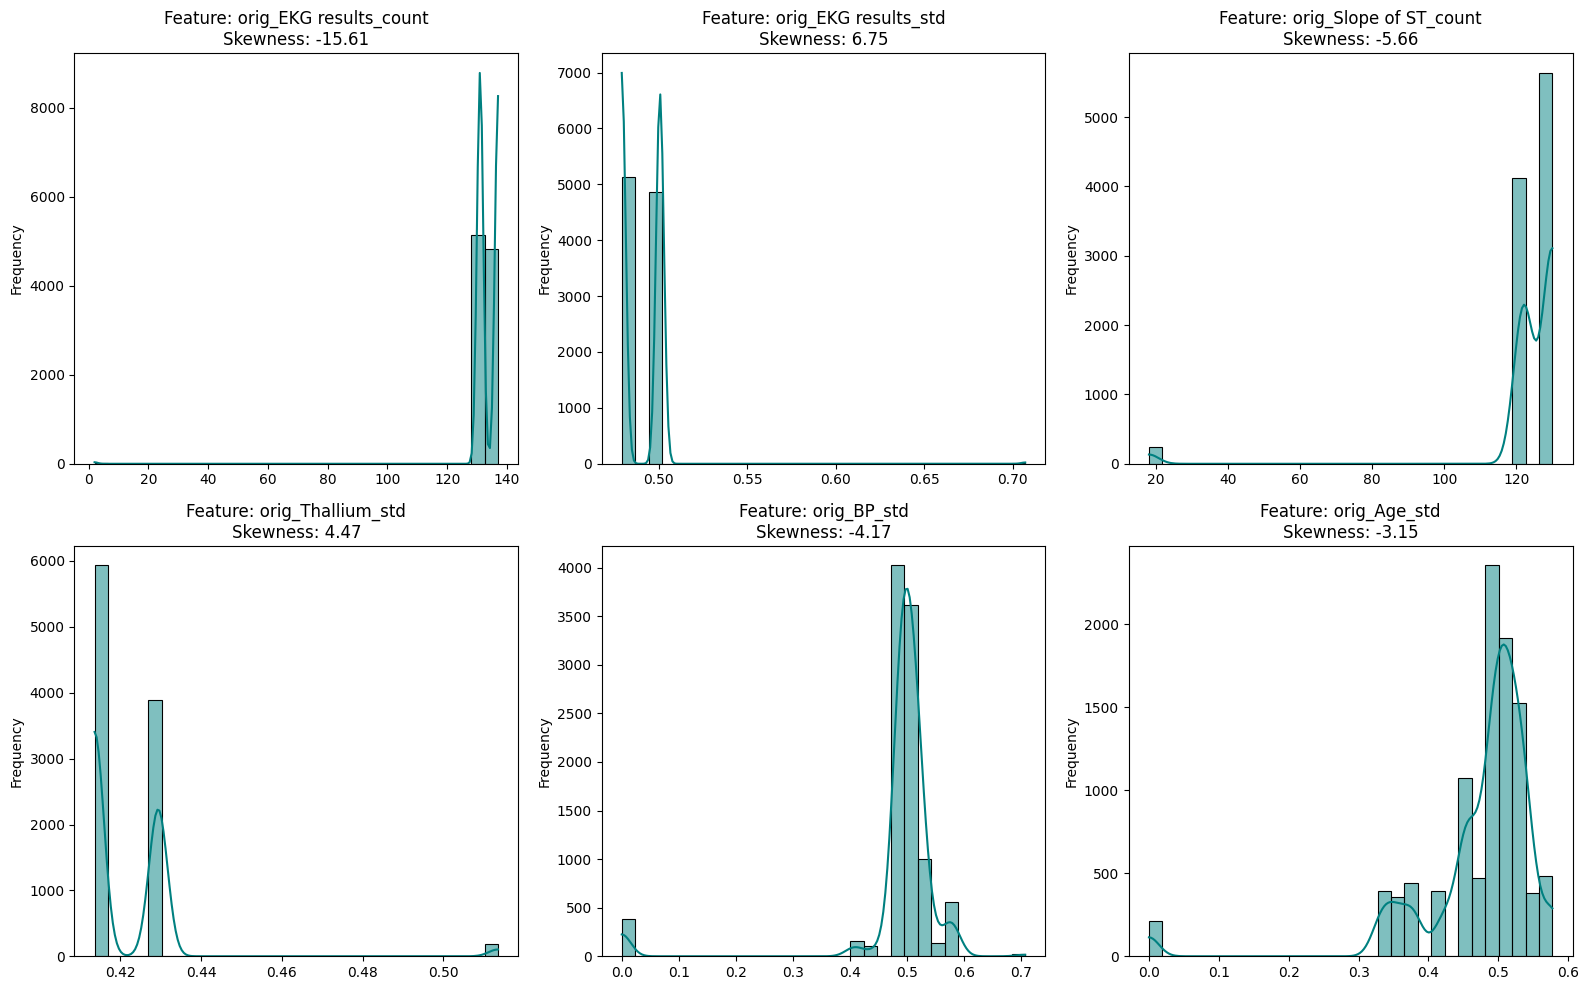

In [7]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1) 
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('skewed_distributions.png')

# Cross-Validation & Training

In [8]:
%%time

param_grid = {
        'device': 'cuda',
        'random_state': 42,
        'verbosity': 2,
        'n_epochs': 100,
        'batch_size': 256, 
        'n_ens': 8, 
        'use_early_stopping': True,
        'early_stopping_additive_patience': 20,
        'early_stopping_multiplicative_patience': 1,
        'act': "mish",
        'embedding_size': 8,
        'first_layer_lr_factor': 0.5962121993798933,
        'hidden_sizes': "rectangular",
        'hidden_width': 384,
        'lr': 0.04, 
        'ls_eps': 0.011498317194338772,
        'ls_eps_sched': "coslog4",
        'max_one_hot_cat_size': 18,
        'n_hidden_layers': 4, 
        'p_drop': 0.07301419697186451,
        'p_drop_sched': "flat_cos",
        'plr_hidden_1': 16, 
        'plr_hidden_2': 8,
        'plr_lr_factor': 0.1151437622270563,
        'plr_sigma': 2.3316811282666916,
        'scale_lr_factor': 2.244801835541429,
        'sq_mom': 1.0 - 0.011834054955582318,
        'wd': 0.02369230879235962,
    } 

for col in X.columns:
    X[col] = X[col].astype(str).astype('category')
    X_test[col] = X_test[col].astype(str).astype('category') 

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_scores = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Starting Fold {fold + 1} ---")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx] 

    model = RealMLP_TD_Classifier(**param_grid) 
    model.fit(X_tr, y_tr.values, X_val, y_val.values) 

    val_probs = model.predict_proba(X_val)[:, 1] 
    fold_test_probs = model.predict_proba(X_test)[:, 1] 

    oof_preds[val_idx] = val_probs
    test_preds += fold_test_probs / N_FOLDS

    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


--- Starting Fold 1 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 'orig_EKG results_median', 'or

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val class_error = 0.110476
Epoch 2/100: val class_error = 0.109976
Epoch 3/100: val class_error = 0.111024
Epoch 4/100: val class_error = 0.109968
Epoch 5/100: val class_error = 0.109587
Epoch 6/100: val class_error = 0.109095
Epoch 7/100: val class_error = 0.108984
Epoch 8/100: val class_error = 0.109532
Epoch 9/100: val class_error = 0.109460
Epoch 10/100: val class_error = 0.109873
Epoch 11/100: val class_error = 0.109595
Epoch 12/100: val class_error = 0.109714
Epoch 13/100: val class_error = 0.109786
Epoch 14/100: val class_error = 0.109563
Epoch 15/100: val class_error = 0.109802
Epoch 16/100: val class_error = 0.109460
Epoch 17/100: val class_error = 0.109484
Epoch 18/100: val class_error = 0.109183
Epoch 19/100: val class_error = 0.109119
Epoch 20/100: val class_error = 0.109230
Epoch 21/100: val class_error = 0.109302
Epoch 22/100: val class_error = 0.109341
Epoch 23/100: val class_error = 0.109238
Epoch 24/100: val class_error = 0.109667
Epoch 25/100: val class_e

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Fold 1 ROC-AUC Score: 0.95609

--- Starting Fold 2 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 

...

Fold 4 ROC-AUC Score: 0.95537

--- Starting Fold 5 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val class_error = 0.111421
Epoch 2/100: val class_error = 0.110825
Epoch 3/100: val class_error = 0.112365
Epoch 4/100: val class_error = 0.111540
Epoch 5/100: val class_error = 0.110651
Epoch 6/100: val class_error = 0.110563
Epoch 7/100: val class_error = 0.110357
Epoch 8/100: val class_error = 0.110960
Epoch 9/100: val class_error = 0.110667
Epoch 10/100: val class_error = 0.110873
Epoch 11/100: val class_error = 0.111341
Epoch 12/100: val class_error = 0.111444
Epoch 13/100: val class_error = 0.110746
Epoch 14/100: val class_error = 0.110762
Epoch 15/100: val class_error = 0.110508
Epoch 16/100: val class_error = 0.110452
Epoch 17/100: val class_error = 0.110310
Epoch 18/100: val class_error = 0.110571
Epoch 19/100: val class_error = 0.110603
Epoch 20/100: val class_error = 0.110706
Epoch 21/100: val class_error = 0.110643
Epoch 22/100: val class_error = 0.110778
Epoch 23/100: val class_error = 0.110429
Epoch 24/100: val class_error = 0.110310
Epoch 25/100: val class_e

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Fold 5 ROC-AUC Score: 0.95616
CPU times: user 1h 12min 50s, sys: 1min 14s, total: 1h 14min 4s
Wall time: 1h 14min 11s


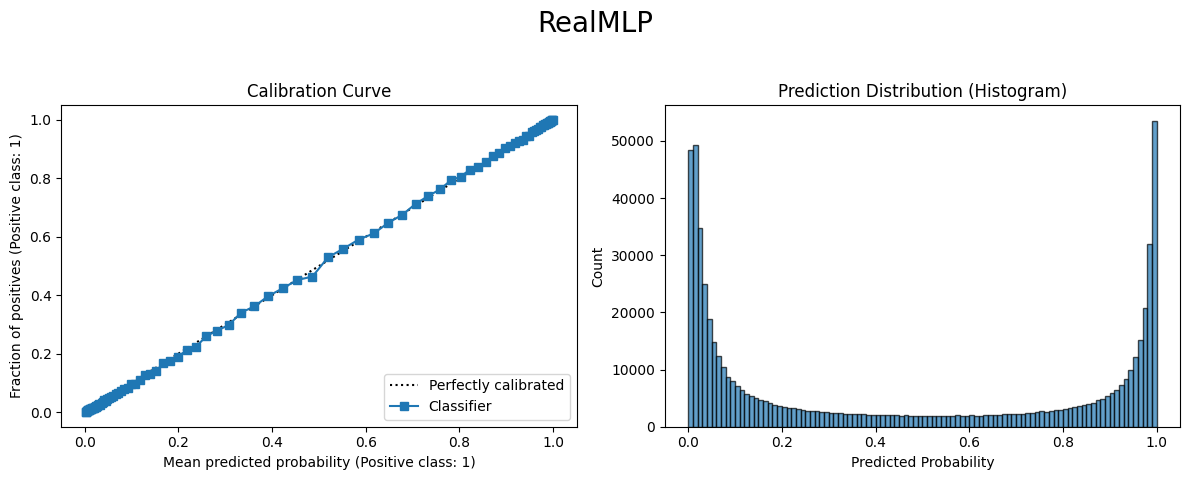

In [9]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5)) 
plt.suptitle('RealMLP', fontsize=20) 

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Evaluation and Submission

In [10]:
total_oof_score = roc_auc_score(y, oof_preds) 

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print("="*40)

pd.DataFrame({'id': train['id'], 'Heart Disease_prob': oof_preds}).to_csv('oof.csv', index=False)

submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)
submission.head() 


Overall OOF ROC-AUC: 0.95552
Mean Fold Score: 0.95565 (+/- 0.00050)


,id,Heart Disease
0,630000,0.948185
1,630001,0.011461
2,630002,0.990032
3,630003,0.006925
4,630004,0.226334
